In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

In [6]:
df=df.drop(columns=["Id"])

In [7]:
# 🔹 1. Why we use LabelEncoder

# Your dataset has:

# Species = ["setosa", "versicolor", "virginica"]

# 👉 These are strings (categorical values)
# 👉 But ML models (including Naïve Bayes) need numbers


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["encoded_species"] = le.fit_transform(df["Species"])


# 🔹 2. What does le.classes_ do?
# le.classes_

# 👉 Output:

# ['setosa', 'versicolor', 'virginica']
# Why useful?
# It tells mapping:
# 0 → setosa
# 1 → versicolor
# 2 → virginica

le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [8]:

#👉 This calculates correlation of all features with encoded_species

df.corr(numeric_only=True)["encoded_species"]

SepalLengthCm      0.782561
SepalWidthCm      -0.419446
PetalLengthCm      0.949043
PetalWidthCm       0.956464
encoded_species    1.000000
Name: encoded_species, dtype: float64

In [9]:
# 👉 Why?

# X = input features (sepal, petal values)
# y = output (encoded labels)

X = df.drop(columns=["Species", "encoded_species"])
y = df["encoded_species"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


# 👉 Rows = Actual
# 👉 Columns = Predicted

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [15]:
# 🔹 STEP 6: Convert Multi-class → Binary (IMPORTANT for TP, FP, TN, FN)

# For exam, take one class (say class 0)

TP = cm[0][0]

FP = cm[:,0].sum() - TP
FN = cm[0,:].sum() - TP
TN = cm.sum() - (TP + FP + FN)

In [16]:
accuracy = (TP + TN) / cm.sum()
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

TP: 10
FP: 0
TN: 20
FN: 0
Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


In [23]:

################################################  ALTERNATE DIRECT LIBRARY WAY (NOT PREFERED)
# 🔹 STEP 9: (Better Method – Recommended)

# Instead of manual calculation:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# 👉 Gives:

# Precision
# Recall
# F1-score
# Support

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



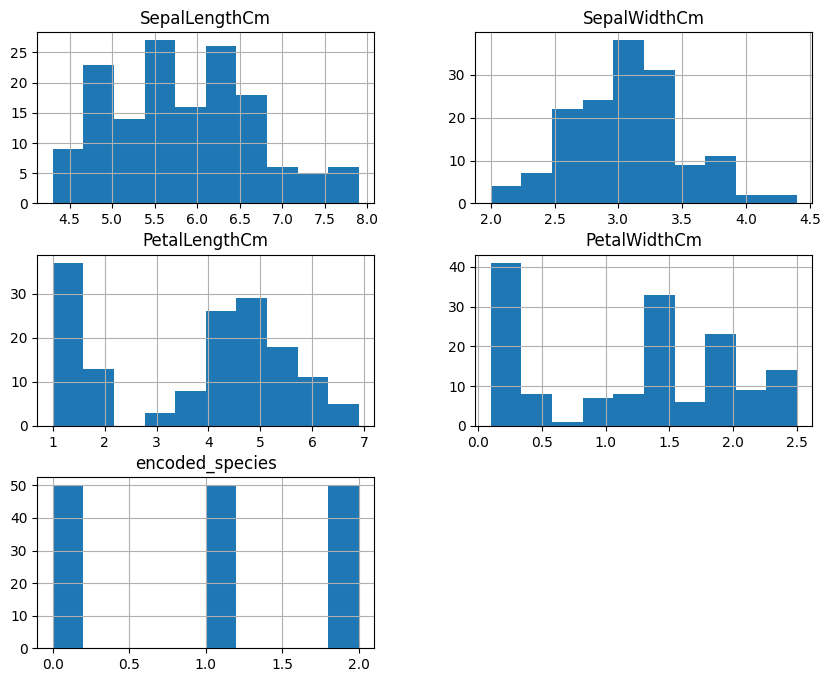

In [25]:
import matplotlib.pyplot as plt

df.hist(figsize=(10,8))
plt.show()

# 🧠 What to write:

# 👉 “Histograms show that features are approximately normally distributed, 
# which supports the assumption of Gaussian Naïve Bayes.”

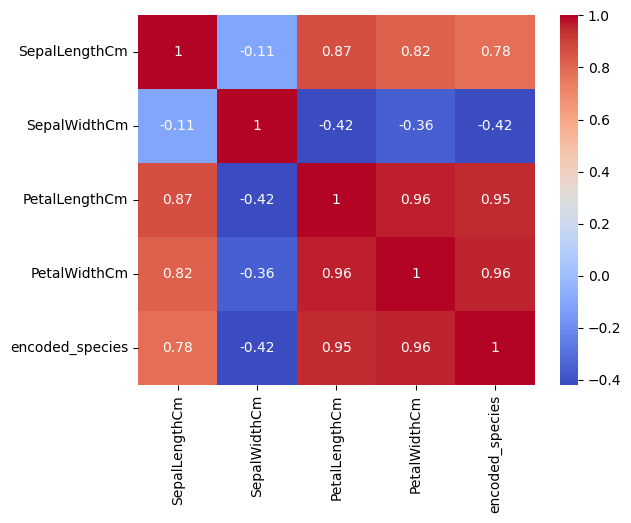

In [27]:
import seaborn as sns
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

# 🧠 What to write:

# 👉 “Petal length and petal width show strong correlation with species,
# making them important features.”

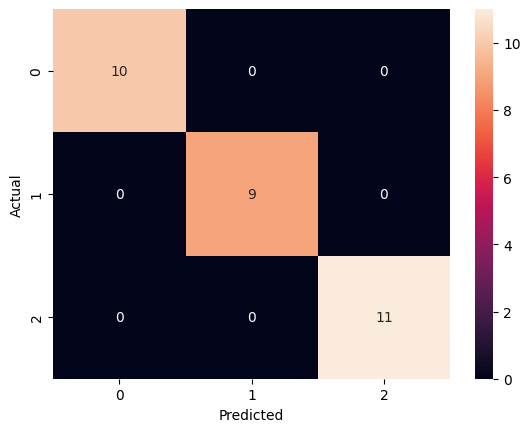

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 🧠 What to write:

# 👉 “Confusion matrix shows correct and incorrect predictions. 
#     Diagonal values represent correct classifications.”

In [24]:
# K-Fold Cross Validation
# K-Fold Cross Validation is a smart way to check if your model is really good — not just lucky on one train-test split.

# Instead of splitting your data into only one train-test,
# ✅ it splits the data into K parts ("folds")
# ✅ trains the model K times
# ✅ tests it each time on a different fold
# ✅ then averages the results.

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", scores.mean())


    

Cross-validation accuracy scores: [0.93333333 0.96666667 0.93333333 0.93333333 1.        ]
Mean accuracy: 0.9533333333333334
